<a href="https://colab.research.google.com/github/saim9211/DeepLearning/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

resources : https://www.learnpytorch.io/01_pytorch_workflow/

In [1]:
import torch
from torch import nn # it contain all building block of the pytorch
import matplotlib.pyplot as plt

In [2]:
# data (preparing  and the loading )

# and the data can in any form (vedios,images,excels,audio,dns,text)
# we use the linear regression formula

#create the *known parameters
weight=0.7
bais=0.3
# create teh data
start=0
end =1
gap=0.02
X=torch.arange(start,end,gap).unsqueeze(dim=1)
y=weight*X+bais
y
print(len(y),len(X))

50 50


In [3]:
# splitting the data in to training and the testing
# creat the split
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_test),len(X_train),len(y_test),len(y_train)


(10, 40, 10, 40)

In [4]:
# visualizing the data
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """ plots the taining data ,test and compare
  """
  plt.figure(figsize=(10,7))
  # plot the training data in blue
  plt.scatter(train_data,train_labels,c="b",s=4,label="training data")
  # are there prediction
  if predictions is not None:
    plt.scatter(train_data,predictions,c="g",s=4,label="prediction")
  # show the legend
  plt.legend(prop={"size":14})

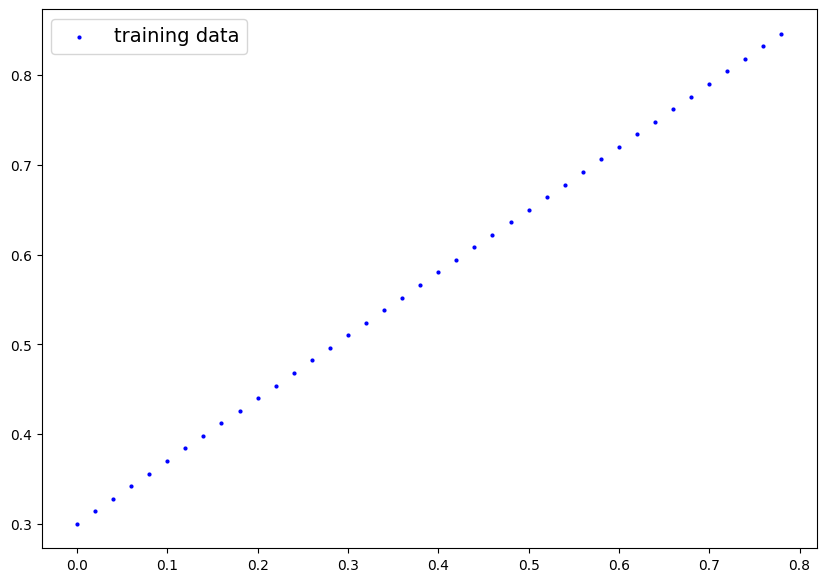

In [5]:
plot_predictions()

### pytorch model building essentials
1. nn.Module base class for neuralworks and contains the larger building blocks (layers)
2. nn.Parameter contains the smaller parameters like weights and biases (put these together to make nn.Module(s))
3. forward() tells the larger blocks how to make calculations on inputs (tensors full of data) within nn.Module(s)
4. torch.optim contains optimization methods on how to improve the parameters within nn.Parameter to better represent input data

In [6]:
class LinearRegressionMode(nn.Module):
  def __init__(self):
    super().__init__()

    self.weights=nn.Parameter(torch.randn(1,
                                          requires_grad=True,
                                          dtype=torch.float))
    self.bais=nn.Parameter(torch.randn(1,
                                       requires_grad=True,
                                       dtype=torch.float))
# forward() define the computation in the model
  def forward(self, x:torch.Tensor)->torch.Tensor:
    return self.weights*x+self.bais

### best cheat sheet for the pytorch basics
url: https://pytorch-cn.com/tutorials/beginner/ptcheat.html

#checking the content of our pytorch model
so we can check our model parameter  or what inside our model  by nn.parameter

In [7]:
# create the random seed
torch.manual_seed(42)
# create the instance of the model
model_0=LinearRegressionMode()
# checking the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
# List the name parameters for better understanding
model_0.state_dict() # it give the values of that we get by in parameters not get the known values we add in start

OrderedDict([('weights', tensor([0.3367])), ('bais', tensor([0.1288]))])

### make the perdiction with our random model using the torch,inference_mode()

1. To check our model predictive power and let see how much well it predict the 'y_test'
2. when we pass data thorugh our model its going to run it  through the forward method


In [9]:
# make the perdiction
with torch.inference_mode():
  y_preds=model_0(X_test)

y_preds







tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [10]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

In [11]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


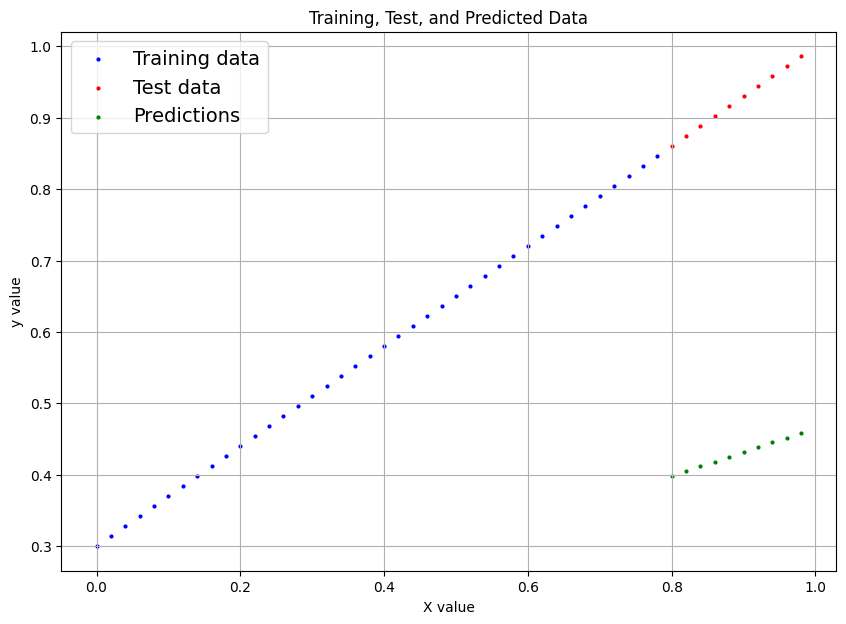

In [12]:
plt.figure(figsize=(10, 7))

# Plot training data
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")

# Plot test data
plt.scatter(X_test, y_test, c="r", s=4, label="Test data")

# Plot model's predictions (y_preds are based on X_test)
plt.scatter(X_test, y_preds.cpu().numpy(), c="g", s=4, label="Predictions")

# Show the legend
plt.legend(prop={"size": 14})
plt.xlabel("X value")
plt.ylabel("y value")
plt.title("Training, Test, and Predicted Data")
plt.grid(True)

### now calculating the loss function and the optimizers here
things we have to focus :
 1. loss function A function to measure how wrong the perfdiction to ideal output ,lower is better.
 2.optimize   take in to account the loss of the modal and adjust  the model parameters

 and in pytorch we need:
 1. training loop
 2. testing loop



In [13]:
# creating the loss function
lse=nn.L1Loss()
# creating the optimizer
optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.01) # adjusting the learningn rate here

from typing import dataclass_transform
#### Building the training and the testing loop
  A couple of things we need in the training loop:
1. loop through the dataclass_transform
2. forward pass ( this involves data moving through our model's forward() functions) to make the prediction - also called the forward propagation
3. calculate the loss
4. optimize the zero grad
5. loss backward -> move backward through network to cal the grad of each parameters with respect to the loss -> backpropagation
5. optimizer set up- use the optimzer to adjust our model paramenter to try and imporve the loss function -> gradient descent


In [71]:
torch.manual_seed(42)
# epoch is one loop through teh data...
epochs=100
#1 loop through the data
for epoch in range(epochs):
  #set the modal in training mode
  model_0.train() # train mode in pytorch set all the parameters that required the gradient to req the gradient
  #2 forward pass
  y_pred=model_0(X_train)
  #3 calculate the loss
  loss=lse(y_pred,y_train)
  print(loss)
  #4 optimizer
  optimizer.zero_grad()
  #5 loss backward
  loss.backward()
  #6 optimizer step
  optimizer.step()


  # testing phase
  model_0.eval()# turn of the gradient tracking

  # print the model state_dict()
  print(model_0.state_dict())

tensor(0.0159, grad_fn=<MeanBackward0>)
OrderedDict({'weights': tensor([0.6227]), 'bais': tensor([0.3323])})
tensor(0.0155, grad_fn=<MeanBackward0>)
OrderedDict({'weights': tensor([0.6245]), 'bais': tensor([0.3318])})
tensor(0.0152, grad_fn=<MeanBackward0>)
OrderedDict({'weights': tensor([0.6261]), 'bais': tensor([0.3308])})
tensor(0.0148, grad_fn=<MeanBackward0>)
OrderedDict({'weights': tensor([0.6279]), 'bais': tensor([0.3303])})
tensor(0.0145, grad_fn=<MeanBackward0>)
OrderedDict({'weights': tensor([0.6295]), 'bais': tensor([0.3293])})
tensor(0.0142, grad_fn=<MeanBackward0>)
OrderedDict({'weights': tensor([0.6313]), 'bais': tensor([0.3288])})
tensor(0.0138, grad_fn=<MeanBackward0>)
OrderedDict({'weights': tensor([0.6331]), 'bais': tensor([0.3283])})
tensor(0.0135, grad_fn=<MeanBackward0>)
OrderedDict({'weights': tensor([0.6347]), 'bais': tensor([0.3273])})
tensor(0.0131, grad_fn=<MeanBackward0>)
OrderedDict({'weights': tensor([0.6365]), 'bais': tensor([0.3268])})
tensor(0.0128, grad

In [72]:
with torch.inference_mode():
  y_preds_new=model_0(X_test)
y_preds_new

tensor([[0.8554],
        [0.8693],
        [0.8832],
        [0.8971],
        [0.9110],
        [0.9249],
        [0.9388],
        [0.9527],
        [0.9666],
        [0.9805]])

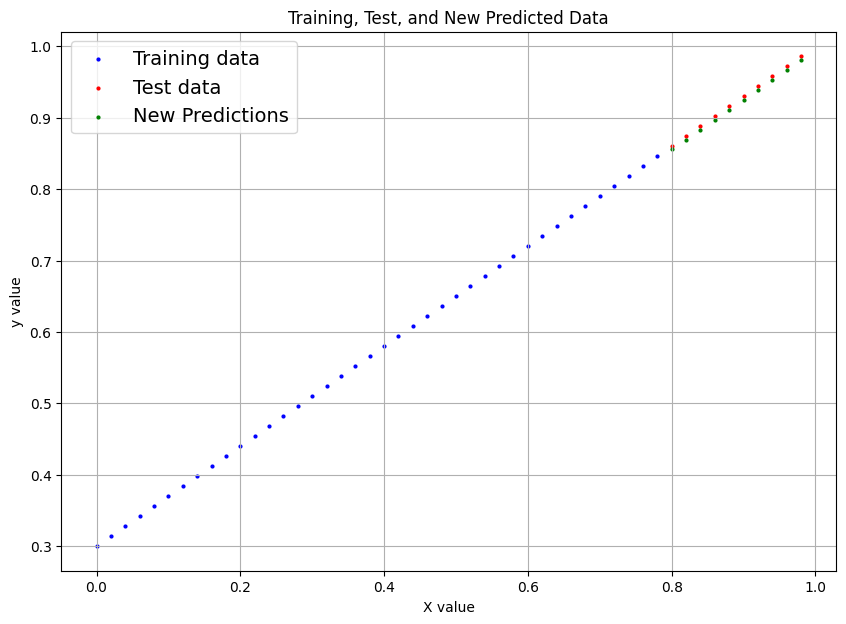

In [73]:
plt.figure(figsize=(10, 7))

# Plot training data
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")

# Plot test data
plt.scatter(X_test, y_test, c="r", s=4, label="Test data")

# Plot model's NEW predictions (y_preds_new are based on X_test)
plt.scatter(X_test, y_preds_new.cpu().numpy(), c="g", s=4, label="New Predictions")

# Show the legend
plt.legend(prop={"size": 14})
plt.xlabel("X value")
plt.ylabel("y value")
plt.title("Training, Test, and New Predicted Data")
plt.grid(True)

In [45]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3874])), ('bais', tensor([0.2588]))])

In [36]:
weight,bais

(0.7, 0.3)